# pairadigm v1.0 Example 

This notebook contains a worked exampe of using the latest version of the `pairadigm` package with an open-source LLM via Ollama to measure hate speech using the Measuring Hate Speech dataset from Kennedy et. al. (2020) and Sachdeva et. al. (2022). 

- Kennedy, C. J., Bacon, G., Sahn, A., & von Vacano, C. (2020). Constructing interval variables via faceted Rasch measurement and multitask deep learning: a hate speech application. arXiv preprint arXiv:2009.10277.
- Pratik Sachdeva, Renata Barreto, Geoff Bacon, Alexander Sahn, Claudia von Vacano, and Chris Kennedy. 2022. The Measuring Hate Speech Corpus: Leveraging Rasch Measurement Theory for Data Perspectivism. In Proceedings of the 1st Workshop on Perspectivist Approaches to NLP @LREC2022, pages 83–94, Marseille, France. European Language Resources Association.

## Getting Started

To run this example as written, you'll need to have a couple things set up: 

- [Ollama](https://ollama.com/) installed on your device. Ollama is an open-source tool designed to run large language models (LLMs)—such as Llama 3, Mistral, and Gemma—locally on your own machine. It streamlines the setup process, offering a simple command-line interface to download and run models, ensuring data privacy and removing internet dependency.
- In Ollama, you'll need to download two models:
    - gemma4:e4b
    - ministral-3:8b
- If you want to/need to just download one model or two smaller models (e.g. gemma4:e2b), go for it! Just note that you'll need to update some of the code below. 

Once that is all downloaded, you'll just need to install the package by uncommenting the next cell and installing pairadigm and its requirements and after that you should be good to go.

In [1]:
# %pip install -r requirements.txt
# !pip install pairadigm

In [ ]:
# %pip install -e .

In [34]:
import pandas as pd
import pairadigm as pdm
from dotenv import load_dotenv
import os
import datasets

# Data

This section of the notebook uses data from the Measuring Hate Speech dataset. The dataset is a large-scale, high-quality corpus designed to move beyond binary "hate vs. not hate" classifications. Developed by researchers at UC Berkeley in collaboration with Google, it consists of approximately 40,000 social media comments labeled by over 11,000 annotators.

What sets this dataset apart is its use of Item Response Theory (IRT) to create a continuous "Hate Speech Score" rather than relying on simple majority rule. This approach accounts for annotator disagreement and nuances in perception, allowing researchers to measure the severity of hate speech across several key dimensions:

- Sentiment: The overall emotional tone.
- Respect: Whether the content treats the target with dignity.
- Insult: The level of inflammatory or derogatory language.
- Humiliation: Intent to shame or degrade.
- Dehumanization: Likening targets to non-human entities.
- Violence: Implicit or explicit threats of physical harm.

By providing these multi-faceted labels and the underlying IRT parameters, the dataset helps developers build models that are more sensitive to the complexities of online discourse and more robust against the biases often found in smaller, less diverse training sets.

For the purpose of this example, we'll be using `pairadigm` to measure hate speech within the same texts and comparing the results. 

In [5]:
# Load and review the data
dataset = datasets.load_dataset('ucberkeley-dlab/measuring-hate-speech')
df = dataset['train'].to_pandas()
df.describe()

,comment_id,annotator_id,platform,sentiment,respect,insult,humiliate,status,dehumanize,violence,...,hatespeech,hate_speech_score,infitms,outfitms,annotator_severity,std_err,annotator_infitms,annotator_outfitms,hypothesis,annotator_age
count,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.00000,135556.000000,135556.000000,135556.000000,135556.000000,...,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135451.000000
mean,23530.416138,5567.097812,1.281352,2.954307,2.828875,2.56331,2.278638,2.698575,1.846211,1.052045,...,0.744733,-0.567428,1.034322,1.001052,-0.018817,0.300588,1.007158,1.011841,0.014589,37.910772
std,12387.194125,3230.508937,1.023542,1.231552,1.309548,1.38983,1.370876,0.898500,1.402372,1.345706,...,0.932260,2.380003,0.496867,0.791943,0.487261,0.236380,0.269876,0.675863,0.613006,11.641276
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.340000,0.100000,0.070000,-1.820000,0.020000,0.390000,0.280000,-1.578693,18.000000
25%,18148.000000,2719.000000,0.000000,2.000000,2.000000,2.00000,1.000000,2.000000,1.000000,0.000000,...,0.000000,-2.330000,0.710000,0.560000,-0.380000,0.030000,0.810000,0.670000,-0.341008,29.000000
50%,20052.000000,5602.500000,1.000000,3.000000,3.000000,3.00000,3.000000,3.000000,2.000000,0.000000,...,0.000000,-0.340000,0.960000,0.830000,-0.020000,0.340000,0.970000,0.850000,0.110405,35.000000
75%,32038.250000,8363.000000,2.000000,4.000000,4.000000,4.00000,3.000000,3.000000,3.000000,2.000000,...,2.000000,1.410000,1.300000,1.220000,0.350000,0.420000,1.170000,1.130000,0.449555,45.000000
max,50070.000000,11142.000000,3.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,...,2.000000,6.300000,5.900000,9.000000,1.360000,1.900000,2.010000,9.000000,0.987511,81.000000


*For this example we'll measure hate speech, but you could try replicating this notebook for any of the other individual constructs annotators identified too.*

In [7]:
# Pull relevant item data for example
cols = ['comment_id', 'text', 'hate_speech_score']
data = df[cols].drop_duplicates().copy()
data

,comment_id,text,hate_speech_score
0,47777,Yes indeed. She sort of reminds me of the elde...,-3.90
1,39773,The trans women reading this tweet right now i...,-6.52
2,47101,Question: These 4 broads who criticize America...,0.36
3,43625,It is about time for all illegals to go back t...,0.26
4,12538,For starters bend over the one in pink and kic...,1.54
...,...,...,...
135546,26287,🔥PUBG JAPAN SERIES 🔥Grade2 Day2 6/7 <Round8> 1...,-3.10
135547,14785,لا تتشمت الرجال مسكين يعاني كس امه 😂. يقول يال...,-0.20
135549,30588,"Umar khalid, sahela rashid, kanhiyan kumar जैस...",-1.69
135550,21008,@AbeShinzo @realDonaldTrump @shinzoabe 独裁者は行きま...,-2.49


In [ ]:
# Pull a sample across bins of the hate speech score
data['bin'] = pd.cut(data['hate_speech_score'], 
                     bins=5, 
                     labels=['0-20', '20-40', '40-60', '60-80', '80-100'])

items_per_bin = 7 
# Feel free to increase this is you're using a closed LLM API, 
# but for local ones on a personal laptop you'll want to keep it small

sample = data.groupby('bin', observed=True).apply(lambda x: x.sample(items_per_bin, random_state=42), 
                                                  include_groups=False).reset_index(drop=True)

print(sample.shape)
sample.head()

(35, 3)


,comment_id,text,hate_speech_score
0,11870,Got it. Thanks for the clarifying and congrats...,-5.65
1,22840,URL helping the rohingya refugees is also anot...,-5.60
2,10695,"That's why that one came here, went through th...",-5.79
3,32523,New Issue from the @GaDjournal on Humanitarian...,-6.21
4,5360,Fellow trans girl here! Love and support confi...,-8.34


# Build pairadigm

The central piece of how pairadigm works is the Concept-Guided Chain-of-Thought (CGCoT) prompting used. These prompts guide how you intend for the LLM to understand the nuance required to accurately measure the construct from text. The goal is to take the comparison task for the LLM from a reasoning task - where it would have to come up with this thought process on its own - to a pattern recognition task. 

You can imagine the way you would help manual annotators consider edge cases in drafting CGCoT prompts. What are the subtlties you expect your annotators to be able to be sensitive to and/or what aspects of the text most relate to the construct that you want to make salient to the annotators? Whatever those levels are determine the number and types of CGCoT prompts you should develop. 

In [9]:
# Transparency: Prompts here were developed with assistance from Gemini Pro 3.1
cgcot_prompts = [
    'Summarize the following text: {text}', 
    'Does the text target a specific group or individual based on demographic characteristics (e.g., race, religion, gender, sexual orientation, disability)? If yes, explicitly AND CONCISELY identify the target. Text: {text}',
    'Does the text use explicit slurs, profanity, or profoundly insulting language specifically directed at the target? If yes, list the specific words or phrases. Text: {text}',
    'Does the text compare the target to non-human entities (e.g., animals, pests, diseases, dirt) or imply they are biologically/morally inferior? BRIEFLY and CONCISELY explain how. Text: {text}',
    'Does the text express a desire for the target to experience violence, discrimination, exclusion, or harm? Text: {text}'
]

In [ ]:
# Initialize the pairadigm
p = pdm.Pairadigm(
    data=sample,
    item_id_name='comment_id', # column with the item identifier
    text_name='text', # column with the text
    cgcot_prompts=cgcot_prompts,
    model_name=['gemma4:e4b', 'ministral-3:8b'], # Feel free to swap in your model(s) of choice here or add a model
    api_key=[None, None], # If using a proprietary API, set these to your API key at the appropriate index
    target_concept='hate speech',
    save_dir="example_save_dir"
)

# Review Clients
p.get_clients_info()

,index,model_name,provider
0,0,gemma4:e4b,ollama
1,1,ministral-3:8b,ollama


Let's make sure the clients can connect before we generate all the breakdowns and pairwise annotations!

In [ ]:
# Testing, testing
p.test_clients_connection(test_prompt='What is the best pizza spot in Detroit?', return_responses=True)

Testing LLM client connections using: 'What is the best pizza spot in Detroit?'...
  gemma4:e4b: MODEL OK
  ministral-3:8b: MODEL OK


{'gemma4:e4b': 'Detroit has several highly regarded pizza spots, with the "best" often depending on personal preference for style (e.g., classic Detroit square, Neapolitan, etc.). Some of the most frequently recommended and acclaimed spots include:\n\n*   **Buddy\'s Pizza:** Famous for its traditional, square, crispy-crust Detroit-style pizza.\n*   **Estates Pizza:** Another highly recognized local favorite known for its Detroit-style crust.\n*   **Kelly\'s Tavern Pizza:** A long-standing local institution.\n*   **Greystone Pizza:** Often praised for its quality and crust.',
 'ministral-3:8b': 'Based on **2023–2024 local rankings, food critics, and community consensus**, the top-tier Detroit pizza spots are:\n\n1. **John’s Pizza** (Downtown, Ferndale, and other locations)\n   - **Why?** Legendary Detroit-style deep-dish with a crispy crust, gooey cheese, and a perfect balance of tomato sauce and toppings. Consistently rated #1 by *Eater Detroit*, *Michigan in Pictures*, and *Detroit Fr

Now that we've setup our pairadigm and made sure the LLMClient(s) we're using can be reached, let's generate the CGCoT breakdowns of every item. These breakdowns are what pairadigm actually pairwise compares. You can see an example further below in the notebook. 

In [ ]:
# Get CGCoT Breakdowns for every item from every model (this takes a while if using a local model)
p.generate_breakdowns()


Generating breakdowns for 35 items using: gemma4:e4b


[gemma4:e4b]: 100%|██████████| 35/35 [17:39<00:00, 30.28s/it]  


Completed: 35/35 items

Generating breakdowns for 35 items using: ministral-3:8b


[ministral-3:8b]: 100%|██████████| 35/35 [05:25<00:00,  9.29s/it]

Completed: 35/35 items

Breakdowns added to [object].data — column(s): CGCoT_Breakdown_gemma4:e4b, CGCoT_Breakdown_ministral-3:8b
Pairadigm saved to: example_save_dir/
  Files written: metadata.json, data.parquet
Auto-saved to: example_save_dir


Let's review some of the breakdowns. 
Note that if you used more than 1 LLMClient, then instead of the breakdown column being called "CGCoT_Breakdown" it will be "CGCoT_Breakdown_[MODEL_NAME]", with 1 column for each model used. 

In [20]:
# View columns
list(p.data.columns)

['comment_id',
 'text',
 'hate_speech_score',
 'CGCoT_Breakdown_gemma4:e4b',
 'CGCoT_Breakdown_ministral-3:8b',
 'split']

In [49]:
# Review some breakdowns (min hate speech score in sample)
print(p.data.loc[p.data['hate_speech_score'] == min(p.data['hate_speech_score']), 'CGCoT_Breakdown_gemma4:e4b'].values[0])

Original Text: Fellow trans girl here! Love and support confirmed!
The core idea is to acknowledge and affirm support from another trans girl.
The text targets transgender women.
The text does not use explicit slurs, profanity, or profoundly insulting language.
The text does not compare the target to non-human entities or imply inferiority.
The text does not express a desire for the target to experience violence, discrimination, exclusion, or harm.


In [ ]:
# Review some breakdowns (max hate speech score in sample) 
# TRIGGER WARNING: This may contain highly offensive content. 
# Proceed with caution if you uncomment and run this cell.

# print(p.data.loc[p.data['hate_speech_score'] == max(p.data['hate_speech_score']), 'CGCoT_Breakdown_gemma4:e4b'].values[0])

Now that we've surfaced the nuance within the text that we want the LLM to attend to, let's generate pairs and paired comparisons. 

Here are a couple of pieces to consider before beginning the process: 

- **How many pairs should every item be in?** The [Wu et. al. (2024)](https://ieeexplore.ieee.org/document/10825235) article that introduced CGCoT examined and found that for political aversion, anywhere from 5 to 20 pairs per item worked well. The more pairs per item the more precise the resulting ranking on the construct for every item, so we'd recommend at least 10 pairs per item (5 is done here for compute considerations).
- **Should you allow for ties?** While there's not clear literature on this yet that we are aware of, in our experience we have found that LLM's annotations are more useful when they *have to make a forced choice*, though even this could have potential caveats if the underlying constuct is rare. Since the training process for the models is so obscure, there are moral choices made by their developers that - for subjective or contentious constructs (like hate speech) - make it so that when provided a Tie option models may over-select it to be inoffensive. This makes validation a bit complex when you want to allow your manual annotators a Tie option, however, to try and distinguish difficult items or faulty training. 
    - One potential solution is to remove any items where a manual annotator chose a Tie and do so until enough pairs are annotated to run validation (we recommend 50-100 pairs, though it is an open question how the number of unique items across those pairs affects validation). 
- **Plans for after the paired comparisons.** If you plan to just use LLMs to annotate a set amount of text, then you should be good to go. One recommendation, though, for those concerned about privacy and deployment considerations - such as costs - is that you might consider trianing an encoder model based on the paired comparisons generated by the LLM. To avoid ["data leakage"](https://www.ibm.com/think/topics/data-leakage-machine-learning#:~:text=For%20time%2Ddependent%20data%2C%20split,any%20unexpected%20changes%20indicating%20leakage.) during model training it's paramount that no item be in pairs with both the training and testing split of your data (for those less familiar with data splitting, learn more [here](https://developers.google.com/machine-learning/crash-course/overfitting/dividing-datasets)), so we allow for a `make_splits` parameter in our method for generating pairs. However, depending on the complexity of your data and downstram intentions, we highly recommend considering managing your data splits independently and then passing paired data to your `Pairadigm` initialiization. 
    - **Mixed set pairs**: Related to the previous point, estimating the scores for items accross splits becomes tricky - if not impossible - to compare if the items share no comparison path from one to another. To assist with generating the most precise scores, we also offer functionality to generate a set of mixed set pairs that *intentionally* span across the splits for score estimation purposes.  

In [ ]:
# Pair items
p.generate_pairings(
    num_pairs_per_item=5, # see above
    make_splits=True, # Whether to make train/test splits or just generate pairs
    breakdowns=True 
    # breakdowns=True let's the object know it should attach the generated breakdowns, 
    # otherwise it will just generate the pairs.
) 

Item-level splits — train: 23, eval: 6, test: 6
Split labels added to self.data['split'].
Pairwise DataFrame created and stored in self.pairwise_df (item-level splits applied)


/Users/mlchrzan/Library/CloudStorage/OneDrive-Personal/Professional/Data Science/Personal Projects/pairadigm/pairadigm/core.py:670: UserWarning:

Item-level splits applied (train/eval/test). Inspect splits before model training.



,item1,item2,item1_split,item2_split,breakdown1_gemma4:e4b,breakdown2_gemma4:e4b,breakdown1_ministral-3:8b,breakdown2_ministral-3:8b
0,3068,35743,train,train,Original Text: MGTOW is fucking gay why don't ...,Original Text: Meet the 23-Year-Old Indian Ori...,Original Text: MGTOW is fucking gay why don't ...,Original Text: Meet the 23-Year-Old Indian Ori...
1,32523,9814,train,train,Original Text: New Issue from the @GaDjournal ...,Original Text: I'll fuck your face while I abu...,Original Text: New Issue from the @GaDjournal ...,Original Text: I'll fuck your face while I abu...
2,3068,11870,train,train,Original Text: MGTOW is fucking gay why don't ...,Original Text: Got it. Thanks for the clarifyi...,Original Text: MGTOW is fucking gay why don't ...,Original Text: Got it. Thanks for the clarifyi...
3,43497,11870,train,train,Original Text: White nationalists will be alwa...,Original Text: Got it. Thanks for the clarifyi...,Original Text: White nationalists will be alwa...,Original Text: Got it. Thanks for the clarifyi...
4,5719,28090,train,train,Original Text: Literally anything racist or wi...,Original Text: @freetobe66 @michaelbeatty3 @1R...,Original Text: Literally anything racist or wi...,Original Text: @freetobe66 @michaelbeatty3 @1R...
...,...,...,...,...,...,...,...,...
95,39586,27488,test,test,Original Text: Whore knows her place as a man'...,Original Text: @r4ndie98 Gay ass cunt!\nThe te...,Original Text: Whore knows her place as a man'...,Original Text: @r4ndie98 Gay ass cunt!\n**Core...
96,39586,17594,test,test,Original Text: Whore knows her place as a man'...,Original Text: Because Muslims are the most vi...,Original Text: Whore knows her place as a man'...,Original Text: Because Muslims are the most vi...
97,42616,17594,test,test,Original Text: Me too! It's the 21st century a...,Original Text: Because Muslims are the most vi...,Original Text: Me too! It's the 21st century a...,Original Text: Because Muslims are the most vi...
98,17594,27488,test,test,Original Text: Because Muslims are the most vi...,Original Text: @r4ndie98 Gay ass cunt!\nThe te...,Original Text: Because Muslims are the most vi...,Original Text: @r4ndie98 Gay ass cunt!\n**Core...


And now the big moment, putting the LLMs to work! 

A quick note: while we don't show it here, you can see the prompts we use for this comparison in the GitHub repo. If you don't find them up to your taste, you can pass both a new `system_prompt` and `comparison_prompt` to the function below. 

In [52]:
# Generate LLM Pairwise Annotations (this also takes a while if using a local model)
p.generate_pairwise_annotations()

[gemma4:e4b] Completed 50/100 comparisons
[gemma4:e4b] Completed 100/100 comparisons
[ministral-3:8b] Completed 50/100 comparisons
[ministral-3:8b] Completed 100/100 comparisons
Pairadigm saved to: example_save_dir/
  Files written: metadata.json, data.parquet, pairwise_df.parquet
Auto-saved to: example_save_dir


,item1,item2,item1_split,item2_split,breakdown1_gemma4:e4b,breakdown2_gemma4:e4b,breakdown1_ministral-3:8b,breakdown2_ministral-3:8b,decision_gemma4:e4b,justification_gemma4:e4b,decision_ministral-3:8b,justification_ministral-3:8b
0,3068,35743,train,train,Original Text: MGTOW is fucking gay why don't ...,Original Text: Meet the 23-Year-Old Indian Ori...,Original Text: MGTOW is fucking gay why don't ...,Original Text: Meet the 23-Year-Old Indian Ori...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** *""Description 1""*\n\n**JUSTI..."
1,32523,9814,train,train,Original Text: New Issue from the @GaDjournal ...,Original Text: I'll fuck your face while I abu...,Original Text: New Issue from the @GaDjournal ...,Original Text: I'll fuck your face while I abu...,ERROR from pairadigm: Could not extract answer...,"FINAL ANSWER: <""Description 2"">\nJUSTIFICATION...",ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** *""Description 2""*\n\n**JUSTI..."
2,3068,11870,train,train,Original Text: MGTOW is fucking gay why don't ...,Original Text: Got it. Thanks for the clarifyi...,Original Text: MGTOW is fucking gay why don't ...,Original Text: Got it. Thanks for the clarifyi...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** *""Description 1""*\n\n**JUSTI..."
3,43497,11870,train,train,Original Text: White nationalists will be alwa...,Original Text: Got it. Thanks for the clarifyi...,Original Text: White nationalists will be alwa...,Original Text: Got it. Thanks for the clarifyi...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** *""Description 1""*\n\n**JUSTI..."
4,5719,28090,train,train,Original Text: Literally anything racist or wi...,Original Text: @freetobe66 @michaelbeatty3 @1R...,Original Text: Literally anything racist or wi...,Original Text: @freetobe66 @michaelbeatty3 @1R...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,**FINAL ANSWER:** **Description 2**\n\n**JUSTI...
...,...,...,...,...,...,...,...,...,...,...,...,...
95,39586,27488,test,test,Original Text: Whore knows her place as a man'...,Original Text: @r4ndie98 Gay ass cunt!\nThe te...,Original Text: Whore knows her place as a man'...,Original Text: @r4ndie98 Gay ass cunt!\n**Core...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,**FINAL ANSWER:** **Description 2**\n\n**JUSTI...
96,39586,17594,test,test,Original Text: Whore knows her place as a man'...,Original Text: Because Muslims are the most vi...,Original Text: Whore knows her place as a man'...,Original Text: Because Muslims are the most vi...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,**FINAL ANSWER:** **Description 2**\n\n**JUSTI...
97,42616,17594,test,test,Original Text: Me too! It's the 21st century a...,Original Text: Because Muslims are the most vi...,Original Text: Me too! It's the 21st century a...,Original Text: Because Muslims are the most vi...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** **""Description 2""**\n\n**JUS..."
98,17594,27488,test,test,Original Text: Because Muslims are the most vi...,Original Text: @r4ndie98 Gay ass cunt!\nThe te...,Original Text: Because Muslims are the most vi...,Original Text: @r4ndie98 Gay ass cunt!\n**Core...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,**FINAL ANSWER:** **Description 1**\n\n**JUSTI...


***NOTE***: In Local LLMs there's been an issue where they struggle to follow the formatting instructions. Because the ways in which they fail have been so varied, we've struggled to find a full fix. However, below is code we've found useful that you can use to extract the answer when that happens. 

In [53]:
p.pairwise_df['decision_gemma4:e4b'] = (
    p.pairwise_df['justification_gemma4:e4b']
    .str.extract(r"FINAL ANSWER:\s*.*?(Description 1|Description 2|Tie).*?")
)

p.pairwise_df['decision_gemma4:e4b'] = p.pairwise_df['decision_gemma4:e4b'].replace({
    'Description 1': 'Text1',
    'Description 2': 'Text2'
})

p.pairwise_df

,item1,item2,item1_split,item2_split,breakdown1_gemma4:e4b,breakdown2_gemma4:e4b,breakdown1_ministral-3:8b,breakdown2_ministral-3:8b,decision_gemma4:e4b,justification_gemma4:e4b,decision_ministral-3:8b,justification_ministral-3:8b
0,3068,35743,train,train,Original Text: MGTOW is fucking gay why don't ...,Original Text: Meet the 23-Year-Old Indian Ori...,Original Text: MGTOW is fucking gay why don't ...,Original Text: Meet the 23-Year-Old Indian Ori...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** *""Description 1""*\n\n**JUSTI..."
1,32523,9814,train,train,Original Text: New Issue from the @GaDjournal ...,Original Text: I'll fuck your face while I abu...,Original Text: New Issue from the @GaDjournal ...,Original Text: I'll fuck your face while I abu...,Text2,"FINAL ANSWER: <""Description 2"">\nJUSTIFICATION...",ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** *""Description 2""*\n\n**JUSTI..."
2,3068,11870,train,train,Original Text: MGTOW is fucking gay why don't ...,Original Text: Got it. Thanks for the clarifyi...,Original Text: MGTOW is fucking gay why don't ...,Original Text: Got it. Thanks for the clarifyi...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** *""Description 1""*\n\n**JUSTI..."
3,43497,11870,train,train,Original Text: White nationalists will be alwa...,Original Text: Got it. Thanks for the clarifyi...,Original Text: White nationalists will be alwa...,Original Text: Got it. Thanks for the clarifyi...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** *""Description 1""*\n\n**JUSTI..."
4,5719,28090,train,train,Original Text: Literally anything racist or wi...,Original Text: @freetobe66 @michaelbeatty3 @1R...,Original Text: Literally anything racist or wi...,Original Text: @freetobe66 @michaelbeatty3 @1R...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,**FINAL ANSWER:** **Description 2**\n\n**JUSTI...
...,...,...,...,...,...,...,...,...,...,...,...,...
95,39586,27488,test,test,Original Text: Whore knows her place as a man'...,Original Text: @r4ndie98 Gay ass cunt!\nThe te...,Original Text: Whore knows her place as a man'...,Original Text: @r4ndie98 Gay ass cunt!\n**Core...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,**FINAL ANSWER:** **Description 2**\n\n**JUSTI...
96,39586,17594,test,test,Original Text: Whore knows her place as a man'...,Original Text: Because Muslims are the most vi...,Original Text: Whore knows her place as a man'...,Original Text: Because Muslims are the most vi...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,**FINAL ANSWER:** **Description 2**\n\n**JUSTI...
97,42616,17594,test,test,Original Text: Me too! It's the 21st century a...,Original Text: Because Muslims are the most vi...,Original Text: Me too! It's the 21st century a...,Original Text: Because Muslims are the most vi...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,"**FINAL ANSWER:** **""Description 2""**\n\n**JUS..."
98,17594,27488,test,test,Original Text: Because Muslims are the most vi...,Original Text: @r4ndie98 Gay ass cunt!\nThe te...,Original Text: Because Muslims are the most vi...,Original Text: @r4ndie98 Gay ass cunt!\n**Core...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,ERROR from pairadigm: Could not extract answer...,**FINAL ANSWER:** **Description 1**\n\n**JUSTI...


In [59]:
# Fix decisions for the spots where the model correctly answered but didn't follow pairadigm's formatting instructions
p.pairwise_df['decision_gemma4:e4b'] = (
    p.pairwise_df['justification_gemma4:e4b']
    .str.extract(r"FINAL ANSWER:\s*.*?(Description 1|Description 2|Tie).*?")
)

p.pairwise_df['decision_gemma4:e4b'] = p.pairwise_df['decision_gemma4:e4b'].replace({
    'Description 1': 'Text1',
    'Description 2': 'Text2'
})

p.pairwise_df['decision_ministral-3:8b'] = (
    p.pairwise_df['justification_ministral-3:8b']
    .str.extract(r".*?FINAL ANSWER:.*?\s*.*?(Description 1|Description 2|Tie).*?")
)

p.pairwise_df['decision_ministral-3:8b'] = p.pairwise_df['decision_ministral-3:8b'].replace({
    'Description 1': 'Text1',
    'Description 2': 'Text2'
})

p.save(save_dir=p.save_dir)

p.pairwise_df

Pairadigm saved to: example_save_dir/
  Files written: metadata.json, data.parquet, pairwise_df.parquet


,item1,item2,item1_split,item2_split,breakdown1_gemma4:e4b,breakdown2_gemma4:e4b,breakdown1_ministral-3:8b,breakdown2_ministral-3:8b,decision_gemma4:e4b,justification_gemma4:e4b,decision_ministral-3:8b,justification_ministral-3:8b
0,3068,35743,train,train,Original Text: MGTOW is fucking gay why don't ...,Original Text: Meet the 23-Year-Old Indian Ori...,Original Text: MGTOW is fucking gay why don't ...,Original Text: Meet the 23-Year-Old Indian Ori...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,Text1,"**FINAL ANSWER:** *""Description 1""*\n\n**JUSTI..."
1,32523,9814,train,train,Original Text: New Issue from the @GaDjournal ...,Original Text: I'll fuck your face while I abu...,Original Text: New Issue from the @GaDjournal ...,Original Text: I'll fuck your face while I abu...,Text2,"FINAL ANSWER: <""Description 2"">\nJUSTIFICATION...",Text2,"**FINAL ANSWER:** *""Description 2""*\n\n**JUSTI..."
2,3068,11870,train,train,Original Text: MGTOW is fucking gay why don't ...,Original Text: Got it. Thanks for the clarifyi...,Original Text: MGTOW is fucking gay why don't ...,Original Text: Got it. Thanks for the clarifyi...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,Text1,"**FINAL ANSWER:** *""Description 1""*\n\n**JUSTI..."
3,43497,11870,train,train,Original Text: White nationalists will be alwa...,Original Text: Got it. Thanks for the clarifyi...,Original Text: White nationalists will be alwa...,Original Text: Got it. Thanks for the clarifyi...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,Text1,"**FINAL ANSWER:** *""Description 1""*\n\n**JUSTI..."
4,5719,28090,train,train,Original Text: Literally anything racist or wi...,Original Text: @freetobe66 @michaelbeatty3 @1R...,Original Text: Literally anything racist or wi...,Original Text: @freetobe66 @michaelbeatty3 @1R...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,Text2,**FINAL ANSWER:** **Description 2**\n\n**JUSTI...
...,...,...,...,...,...,...,...,...,...,...,...,...
95,39586,27488,test,test,Original Text: Whore knows her place as a man'...,Original Text: @r4ndie98 Gay ass cunt!\nThe te...,Original Text: Whore knows her place as a man'...,Original Text: @r4ndie98 Gay ass cunt!\n**Core...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,Text2,**FINAL ANSWER:** **Description 2**\n\n**JUSTI...
96,39586,17594,test,test,Original Text: Whore knows her place as a man'...,Original Text: Because Muslims are the most vi...,Original Text: Whore knows her place as a man'...,Original Text: Because Muslims are the most vi...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,Text2,**FINAL ANSWER:** **Description 2**\n\n**JUSTI...
97,42616,17594,test,test,Original Text: Me too! It's the 21st century a...,Original Text: Because Muslims are the most vi...,Original Text: Me too! It's the 21st century a...,Original Text: Because Muslims are the most vi...,Text2,FINAL ANSWER: Description 2\nJUSTIFICATION: De...,Text2,"**FINAL ANSWER:** **""Description 2""**\n\n**JUS..."
98,17594,27488,test,test,Original Text: Because Muslims are the most vi...,Original Text: @r4ndie98 Gay ass cunt!\nThe te...,Original Text: Because Muslims are the most vi...,Original Text: @r4ndie98 Gay ass cunt!\n**Core...,Text1,FINAL ANSWER: Description 1\nJUSTIFICATION: De...,Text1,**FINAL ANSWER:** **Description 1**\n\n**JUSTI...


# Evaluate

The next central tenent of `pairadigm` is validation. This typically takes the form of comparing the LLMs outputs to manual annotations as one piece of evidence we offer to help craft a validity argument. However, since the dataset we're using did not use paired comparisons to annotate, here we just compare the two LLM models to themselves for now. Toward the end of the notebook, we offer a more robust example. A forthcoming paper+code will be released soon that also has a much more fleshed out validation example. 

In [ ]:
# Check for any remaining ERRORs
mask = (p.pairwise_df['decision_gemma4:e4b'] != 'Text1') & (p.pairwise_df['decision_gemma4:e4b'] != 'Text2')
print(f"Gemma4 Errors: {len(p.pairwise_df[mask])}")

mask = (p.pairwise_df['decision_ministral-3:8b'] != 'Text1') & (p.pairwise_df['decision_ministral-3:8b'] != 'Text2')
print(f"Ministral Errors: {len(p.pairwise_df[mask])}") # here we see Ministral still somehow failed 4 more cases -_-, our methods will ignore these pairs

Gemma4 Errors: 0
Ministral Errors: 4


*Over it, ministral* 🙄

One of the most straightforward ways to check individual annotator quality is their internal consistency. Paired comparisons offer a wonderfully straightforward way to measure this: the transitivity of every annotator. 

As a refresher, the transitive property states that if $A>B$ and $B>C$, then $A>C$. 

Thus, to check annotator quality for a unidimensional scalar construct, a bare minimal requirement is that the annotator agrees with themselves across connected pairs, which is what transitivity tells us. 

Here, we give the percentage of triplets that exist in the paired data that the annotator was transitive. 

In [ ]:
# Small check of rater consistency - are the pairwise annotations transitive?
p.check_transitivity()
# {[MODEL]: ([SCORE], [Number of VIOLATIONS], [Number of TRIPLETS])}

{'decision_gemma4:e4b': (0.9836065573770492, 1, 61),
 'decision_ministral-3:8b': (0.9827586206896551, 1, 58)}

Two of the *most common* statistical frameworks for evaluating how consistent different raters perform are **Inter-Rater Reliability (IRR)** and the **Intraclass Correlation Coefficient (ICC)**.

**Inter-Rater Reliability (IRR)**

IRR - sometimes called Inter-Annotator Agreement (IAA) - is a broad concept used to determine the degree of agreement between two or more independent raters. When dealing with categorical or nominal data, researchers often use metrics like **Cohen’s Kappa** (for two raters) or **Krippendorff's Alpha**/**Fleiss’ Kappa** (for multiple raters). These statistics are more robust than simple "percent agreement" because **they account for the possibility of raters agreeing by pure chance**.

**Intraclass Correlation Coefficient (ICC)**

The ICC is a more sophisticated tool typically used for continuous or ordinal data. Unlike standard correlation (like Pearson’s $r$), which only measures linear association, ICC evaluates both **consistency** and **absolute agreement**. It is particularly powerful because it can account for structured sources of error, such as one rater being consistently more "lenient" or "strict" than another. 

**Choosing the Right Metric**

Selecting between these depends heavily on the nature of your data and your study design:

- **Data Type:** Use Kappa-based IRR for categories (e.g., "Pass/Fail" or "Theme A/Theme B"). Use ICC for scales (e.g., a 1–10 score). Since we use paired comparisons, we will typically opt for IRR based metrics.
- **Rater Selection:** ICC allows you to specify whether your raters are the only ones of interest (Fixed Effects) or represent a larger population of potential raters (Random Effects). These raters could be manual annotators or LLMs. 
- **Quality Goal:** If you need your raters to give the *exact* same score, you look for **absolute agreement**. If you only care that they rank items in the same relative order, you look for **consistency**.

In [10]:
# Check the IRR between the LLMs 
p.irr()


INTER-RATER RELIABILITY RESULTS

LLM ANNOTATORS:
  Method: Cohens Kappa
  Score: 0.729
  Interpretation: Substantial
  Annotators: 2
  Items: 96

ALL ANNOTATORS:
  Method: Cohens Kappa
  Score: 0.729
  Interpretation: Substantial
  Annotators: 2
  Items: 96



,group,method,score,n_annotators,n_items,interpretation,error
0,llm,cohens_kappa,0.729167,2,96,Substantial,None
1,all,cohens_kappa,0.729167,2,96,Substantial,None


In [ ]:
# Check the ICC (not entirely appropriate here, but just for demonstration)
p.icc()

  ICC ANALYSIS (ICC(2,1) — two-way random, absolute agreement)

[LLM]
  ICC(2,1): 0.7312 [0.6217, 0.8118] 95% CI
  F(95, 95) = 6.424, p = 0.0000
  Interpretation: Moderate
  Raters: 2, Items: 96

[ALL]
  ICC(2,1): 0.7312 [0.6217, 0.8118] 95% CI
  F(95, 95) = 6.424, p = 0.0000
  Interpretation: Moderate
  Raters: 2, Items: 96



/Users/mlchrzan/Library/CloudStorage/OneDrive-Personal/Professional/Data Science/Personal Projects/pairadigm/pairadigm/validation.py:1074: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mat = pairwise_df[available].applymap(
/Users/mlchrzan/Library/CloudStorage/OneDrive-Personal/Professional/Data Science/Personal Projects/pairadigm/pairadigm/validation.py:1074: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mat = pairwise_df[available].applymap(


,group,icc,ci_lower,ci_upper,f_stat,df1,df2,p_value,n_annotators,n_items,interpretation
0,llm,0.73123,0.621656,0.811805,6.423729,95,95,1.004716e-17,2,96,Moderate
1,all,0.73123,0.621656,0.811805,6.423729,95,95,1.004716e-17,2,96,Moderate


The **Dawid-Skene (DS) model** is a seminal probabilistic framework used to aggregate noisy labels from multiple raters to infer the "ground truth." Originally developed for medical diagnosis in 1979, it has since become the gold-standard baseline for crowdsourcing and data annotation projects.

**How the Model Works**

Unlike simple **Majority Voting**, which treats all raters as equally reliable, the Dawid-Skene model uses an **Expectation-Maximization (EM)** algorithm to simultaneously estimate:

1.  **The True Label:** The most likely "correct" answer for each item.
2.  **Rater Reliability:** The specific error patterns for each individual annotator.

**Rater Reliabilities: The Confusion Matrix**

The core output regarding rater reliability is an individual **Confusion Matrix** for each annotator. This provides a more granular view of reliability than a single "accuracy" score:

* **Sensitivity and Specificity:** The model captures if a rater is prone to specific types of errors (e.g., a rater who consistently labels "Hard" tasks as "Easy," but rarely vice-versa).
* **Bias Detection:** It can identify "yeasayers" or "naysayers" by looking at the off-diagonal values of their confusion matrix.
* **Weighted Influence:** Once a rater’s reliability is estimated, the model assigns more weight to "expert" raters (those with high diagonal values in their matrix) and less weight to "noisy" or "random" raters when determining the final label.

**Key Metrics & Outputs**

| Metric | Description |
| :--- | :--- |
| **Error Rates** | The probability that rater $j$ will provide label $k$ when the true label is $l$. |
| **Class Marginals** | The overall prevalence of each category within the dataset. |
| **Posterior Probabilities** | The confidence level (0–100%) that the aggregated label is actually correct. |

**Limitations**

While powerful, the standard model assumes that **rater errors are independent** and that **task difficulty is uniform**. In practice, some items are inherently harder to label than others, which has led to modern extensions like **GLAD** (Generative Model of Labels, Abilities, and Difficulties) or **Fast Dawid-Skene** for real-time applications. Encorporating these extensions is an active area of developement for `pairadigm`, for which we welcome contributions! 

In [11]:
# Run a Dawid-Skene model to evaluate the LLMs
p.dawid_skene_annotator_ranking(random_seed=42)

Ranking 2 annotators across 100 instances...

DAWID-SKENE ANNOTATOR RANKING
Converged at iteration: 83

Top 5 Most Reliable Annotators:
   rank                annotator  reliability type
0     1  decision_ministral-3:8b     0.932888  LLM
1     2      decision_gemma4:e4b     0.920052  LLM




,annotator,reliability,type,rank
0,decision_ministral-3:8b,0.932888,LLM,1
1,decision_gemma4:e4b,0.920052,LLM,2


# Score

Typically at this point, you would go on to take the best performing LLM that you validate with *manual, human* annotations via the AltTest (discussed below) and/or a Dawid-Skene like test and then use it to annotate your entire dataset in another `pairadigm` instance before using those annotations to score all your items. **However**, as mentioned, we haven't encorporated the annotators for this data due to lack of paired comparisons, so since `ministral-3:8b` had a slightly higher DS reliability, we'll go with that model for now for scoring.  

You'll note that when `score_items()` runs it provided two versions of the score: and "full" and a "split". The "full" version is the score incorporating the mixed pairs mentioned earlier and thus is the more precise estimate. However, due to data leakage, that column should not be used for model training. 

We also estimate the standard error (SE) for the estimate and provide it. The more `num_pairs_per_item` you provided the more precise (smaller) these will be. 

In [11]:
# Score the items and normalize using the min and max of the original scale
p.score_items(
    decision_col='decision_ministral-3:8b',
    normalization_scale=(min(p.data['hate_speech_score']), max(p.data['hate_speech_score']))
)

[ministral-3:8b [full]] Fitting Bradley-Terry model...
[ministral-3:8b [split]] Fitting Bradley-Terry model...
[ministral-3:8b full] Mean hate speech score: -1.124
[ministral-3:8b full] Std  hate speech score: 3.676
[ministral-3:8b split] Bradley-Terry model fitted with 96 within-split comparisons
[ministral-3:8b split] Mean hate speech score: -1.124
[ministral-3:8b split] Std  hate speech score: 3.676

Summary statistics (Bradley_Terry_Score_full_ministral-3:8b):
  mean: -1.124
  median: -1.532
  std: 3.676
  min: -8.340
  max: 5.100
  count: 35.000

Summary statistics (Bradley_Terry_Score_split_ministral-3:8b):
  mean: -1.124
  median: -1.532
  std: 3.676
  min: -8.340
  max: 5.100
  count: 35.000
Pairadigm saved to: example_save_dir/
  Files written: metadata.json, data.parquet, pairwise_df.parquet, scored_df.parquet
Auto-saved to: example_save_dir


/Users/mlchrzan/Library/CloudStorage/OneDrive-Personal/Professional/Data Science/Personal Projects/pairadigm/pairadigm/scoring.py:346: UserWarning: Some rows filtered out due to invalid decision values. Using 96/100 comparisons.
  warnings.warn(


,comment_id,text,hate_speech_score,CGCoT_Breakdown_gemma4:e4b,CGCoT_Breakdown_ministral-3:8b,split,Bradley_Terry_Score_full_ministral-3:8b,Bradley_Terry_SE_full_ministral-3:8b,Bradley_Terry_Score_split_ministral-3:8b,Bradley_Terry_SE_split_ministral-3:8b
0,11870,Got it. Thanks for the clarifying and congrats...,-5.65,Original Text: Got it. Thanks for the clarifyi...,Original Text: Got it. Thanks for the clarifyi...,train,-4.064446,6.395098,-4.064446,6.395098
1,22840,URL helping the rohingya refugees is also anot...,-5.60,Original Text: URL helping the rohingya refuge...,Original Text: URL helping the rohingya refuge...,eval,-8.340000,3.748936,-8.340000,3.748936
2,10695,"That's why that one came here, went through th...",-5.79,"Original Text: That's why that one came here, ...","Original Text: That's why that one came here, ...",train,0.168993,9.725738,0.168993,9.725738
3,32523,New Issue from the @GaDjournal on Humanitarian...,-6.21,Original Text: New Issue from the @GaDjournal ...,Original Text: New Issue from the @GaDjournal ...,train,-2.651285,8.242026,-2.651285,8.242026
4,5360,Fellow trans girl here! Love and support confi...,-8.34,Original Text: Fellow trans girl here! Love an...,Original Text: Fellow trans girl here! Love an...,train,-5.301042,6.372275,-5.301042,6.372275
5,20877,Wait— Dudes are clowning this kid and calling ...,-6.90,Original Text: Wait— Dudes are clowning this k...,Original Text: Wait— Dudes are clowning this k...,train,-1.531763,8.172727,-1.531763,8.172727
6,7153,"Such an amazing culture and religion, they're ...",-5.70,Original Text: Such an amazing culture and rel...,Original Text: Such an amazing culture and rel...,train,-6.636284,5.069665,-6.636284,5.069665
7,21374,"O Allah, forgive him and elevate his station a...",-3.15,"Original Text: O Allah, forgive him and elevat...","Original Text: O Allah, forgive him and elevat...",train,-5.048380,5.253916,-5.048380,5.253916
8,35743,Meet the 23-Year-Old Indian Origin Doctor Bhas...,-2.81,Original Text: Meet the 23-Year-Old Indian Ori...,Original Text: Meet the 23-Year-Old Indian Ori...,train,-1.741927,7.985527,-1.741927,7.985527
9,5719,Literally anything racist or with the nword,-2.49,Original Text: Literally anything racist or wi...,Original Text: Literally anything racist or wi...,train,-3.608074,6.729396,-3.608074,6.729396


Love a good visualization? `pairadigm` offers a few views to help wrap your mind around what's been done so far. The first is for the scores, the 2nd is for the paired comparisons. 

In [10]:
p.plot_score_distribution(score_col="Bradley_Terry_Score_full_ministral-3:8b")

In [ ]:
p.plot_comparison_network(
    decision_col='decision_ministral-3:8b',
    centrality_measure='bradley_terry', # we offer a few different ways to examine this
    data_df = p.data,
    scored_df = p.scored_df,
    score_col='Bradley_Terry_Score_full_ministral-3:8b'
)

# Compare

Now that we've scored the items we sample, let's compare their BT estimated score to the hatespeech score in the original study! 

In [15]:
# Load the scored data if not already in memory
scored_data = p.scored_df.copy()

# 1. Basic correlation analysis
correlation = scored_data['Bradley_Terry_Score_full_ministral-3:8b'].corr(scored_data['hate_speech_score'])
print(f"Pearson Correlation: {correlation:.4f}")

# 2. Additional correlation metrics
from scipy.stats import spearmanr, kendalltau
spearman_corr, spearman_p = spearmanr(scored_data['Bradley_Terry_Score_full_ministral-3:8b'], 
                                       scored_data['hate_speech_score'])
kendall_corr, kendall_p = kendalltau(scored_data['Bradley_Terry_Score_full_ministral-3:8b'], 
                                      scored_data['hate_speech_score'])
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4f})")
print(f"Kendall Correlation: {kendall_corr:.4f} (p-value: {kendall_p:.4f})")

# 3. Summary statistics comparison
print("\nBradley_Terry_Score_full:")
print(scored_data['Bradley_Terry_Score_full_ministral-3:8b'].describe())
print("\nhate_speech_score:")
print(scored_data['hate_speech_score'].describe())

# 4. Scatter plot comparison with Plotly
import plotly.graph_objects as go

# Function to wrap text
def wrap_text(text, width=60):
    """Wrap text to a specified width with line breaks"""
    if pd.isna(text):
        return "N/A"
    text = str(text)
    words = text.split()
    lines = []
    current_line = []
    current_length = 0
    
    for word in words:
        if current_length + len(word) + 1 > width and current_line:
            lines.append(' '.join(current_line))
            current_line = [word]
            current_length = len(word)
        else:
            current_line.append(word)
            current_length += len(word) + 1
    
    if current_line:
        lines.append(' '.join(current_line))
    
    return '<br>'.join(lines)

# Apply text wrapping
scored_data['text_wrapped'] = scored_data['text'].apply(wrap_text)

# Get the range of the original hate_speech_score
min_score = scored_data['hate_speech_score'].min()
max_score = scored_data['hate_speech_score'].max()

# Create the scatter plot
fig = go.Figure()

# Add scatter points
fig.add_trace(go.Scatter(
    x=scored_data['hate_speech_score'],
    y=scored_data['Bradley_Terry_Score_full_ministral-3:8b'],
    mode='markers',
    marker=dict(size=8, opacity=0.6, color='steelblue'),
    text=scored_data['text_wrapped'],
    hovertemplate='<b>Original Score:</b> %{x:.3f}<br>' +
                  '<b>Bradley-Terry Score:</b> %{y:.3f}<br>' +
                  '<b>Text:</b><br>%{text}<br>' +
                  '<extra></extra>',
    name='Items'
))

# Add perfect agreement line
fig.add_trace(go.Scatter(
    x=[min_score, max_score],
    y=[min_score, max_score],
    mode='lines',
    line=dict(color='red', dash='dash'),
    name='Perfect Agreement',
    hoverinfo='skip'
))

# Update layout
correlation_text = (f'Pearson r = {correlation:.4f}<br>'
                   f'Spearman ρ = {spearman_corr:.4f}<br>'
                   f'Kendall τ = {kendall_corr:.4f}')

fig.update_layout(
    title='Comparison of Scores (Both on Same Scale)',
    xaxis_title='Original hate_speech_score',
    yaxis_title='Bradley_Terry_Score_full',
    hovermode='closest',
    width=1000,
    height=700,
    annotations=[dict(
        text=correlation_text,
        x=0.02,
        y=0.98,
        xref='paper',
        yref='paper',
        showarrow=False,
        bgcolor='rgba(255, 228, 181, 0.8)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=10),
        align='left'
    )]
)

fig.update_xaxes(range=[min_score - 0.05, max_score + 0.05])
fig.update_yaxes(range=[min_score - 0.05, max_score + 0.05])

fig.show()

# 5. Calculate residuals/difference
scored_data['score_difference'] = scored_data['Bradley_Terry_Score_full_ministral-3:8b'] - scored_data['hate_speech_score']
print(f"\nMean Difference: {scored_data['score_difference'].mean():.4f}")
print(f"Std Dev of Difference: {scored_data['score_difference'].std():.4f}")

Pearson Correlation: 0.6592
Spearman Correlation: 0.6541 (p-value: 0.0000)
Kendall Correlation: 0.4286 (p-value: 0.0003)

Bradley_Terry_Score_full:
count    35.000000
mean     -1.124139
std       3.675895
min      -8.340000
25%      -3.789200
50%      -1.531763
75%       2.015471
max       5.100000
Name: Bradley_Terry_Score_full_ministral-3:8b, dtype: float64

hate_speech_score:
count    35.000000
mean     -0.857143
std       3.640829
min      -8.340000
25%      -2.980000
50%      -0.220000
75%       1.640000
max       5.100000
Name: hate_speech_score, dtype: float64



Mean Difference: -0.2670
Std Dev of Difference: 3.0205


## **Interpretation: pairadigm Bradley–Terry Scores vs. Original Hate Speech Scores**

**Overall Validation: Moderate Agreement**

The pairadigm-derived Bradley–Terry scores show **moderate convergent validity** with the original hate speech ratings. All three correlation coefficients indicate a meaningful—but not strong—relationship:

- **Pearson correlation (r = 0.6592)** reflects a moderate linear association between the two scoring systems. The BT scores track the general direction of the original ratings but with noticeable dispersion.
- **Spearman correlation (ρ = 0.6541)** shows that the rank ordering is preserved to a similar degree, suggesting the LLM-based pairwise comparisons capture the ordinal structure of the construct reasonably well.
- **Kendall’s tau (τ = 0.4286)** is lower but still indicates substantial concordance. The presence of discordant pairs suggests areas where human and LLM judgments diverge, yet the overall pattern remains aligned.

Together, these values point to a **consistent but not tight** relationship—appropriate for a construct as nuanced and context-dependent as hate speech. This is unsurprising given that: 

1. We only took a sample of 35 observations and 
2. We only used smaller Local LLMs, which have been known to struggle with matching manual annotation quality. 

**Scale Alignment**

The distributional comparison between the two scoring systems shows very strong scale alignment after normalization. The Bradley–Terry scores and the original hate speech scores exhibit:

- Nearly identical means (–1.12 vs. –0.86), differing by only –0.267, which is trivial relative to the constructs’ full range.
- Highly similar standard deviations (3.68 vs. 3.64), indicating that both scoring systems capture comparable variability in item severity.
- Perfectly matched minimum and maximum values (–8.34 to 5.10), confirming that the normalization procedure successfully anchored the BT scores to the empirical bounds of the original scale.
- Comparable quartiles, with only modest differences in the 25th, 50th, and 75th percentiles, suggesting that the two distributions share a similar shape even in the middle of the range.

The standard deviation of the difference scores (3.02) indicates that while individual items show some dispersion around the line of perfect agreement, the overall alignment is tight given the complexity of the construct. Together, these statistics show that the Bradley–Terry transformation preserves the scale geometry of the original ratings while enabling a pairwise-comparison–based measurement approach.

**Implications**

This updated analysis reinforces that the `pairadigm` framework—using concept-guided chain-of-thought prompting and pairwise LLM comparisons—produces **valid, interpretable measurements** that relate meaningfully to established metrics.

The **moderate correlations** are not a weakness; they reflect the inherent complexity of hate speech annotation and the fact that pairwise reasoning may surface subtle distinctions that the prior scalar ratings obscure. The method appears to preserve the construct while introducing a different, potentially more stable measurement geometry.

Overall, the results support the use of Bradley–Terry–derived scores as a **credible, psychometrically grounded alternative** to traditional Likert-style hate speech ratings, especially when scaling to larger datasets or when annotation consistency is a priority.

# Classify

From the continuous scale above, you might think "well, the continuous scores are a bit off, but 0 is supposed to be a cutpoint on the original scale so the paired comparisons at least make a decent classifier!" 

Well have we got news for you - `pairadigm` has a `classify()` method built in just for that purpose! 

NOTE: Without normalization, a naive way to reduce the BT scores into a binary classifier is just taking above and below the mean. The `classify()` method here provides something a bit more sophisticated. 

In [ ]:
# Note, you don't have to save them separately, just doing this here for the visualization. 
# classify() will also autosave to scored_df and its parquet in the save_dir location

classifications = p.classify(
    score_col="Bradley_Terry_Score_full_ministral-3:8b",
    method='kmeans', # also has support for GMM and HDBSCAN
    n_clusters=2 # finds binary categories
);

Classified 35 items into 2 clusters using kmeans on 'Bradley_Terry_Score_full_ministral-3:8b'.
                 count   mean    std    min    25%    50%    75%    max
kmeans_clusters                                                        
0                 18.0 -4.233  2.100 -8.340 -5.238 -3.789 -2.701 -1.532
1                 17.0  2.168  1.279  0.169  1.420  2.015  2.747  5.100
Pairadigm saved to: example_save_dir/
  Files written: metadata.json, data.parquet, pairwise_df.parquet, scored_df.parquet
Auto-saved updated scored dataframe with cluster assignments to: example_save_dir


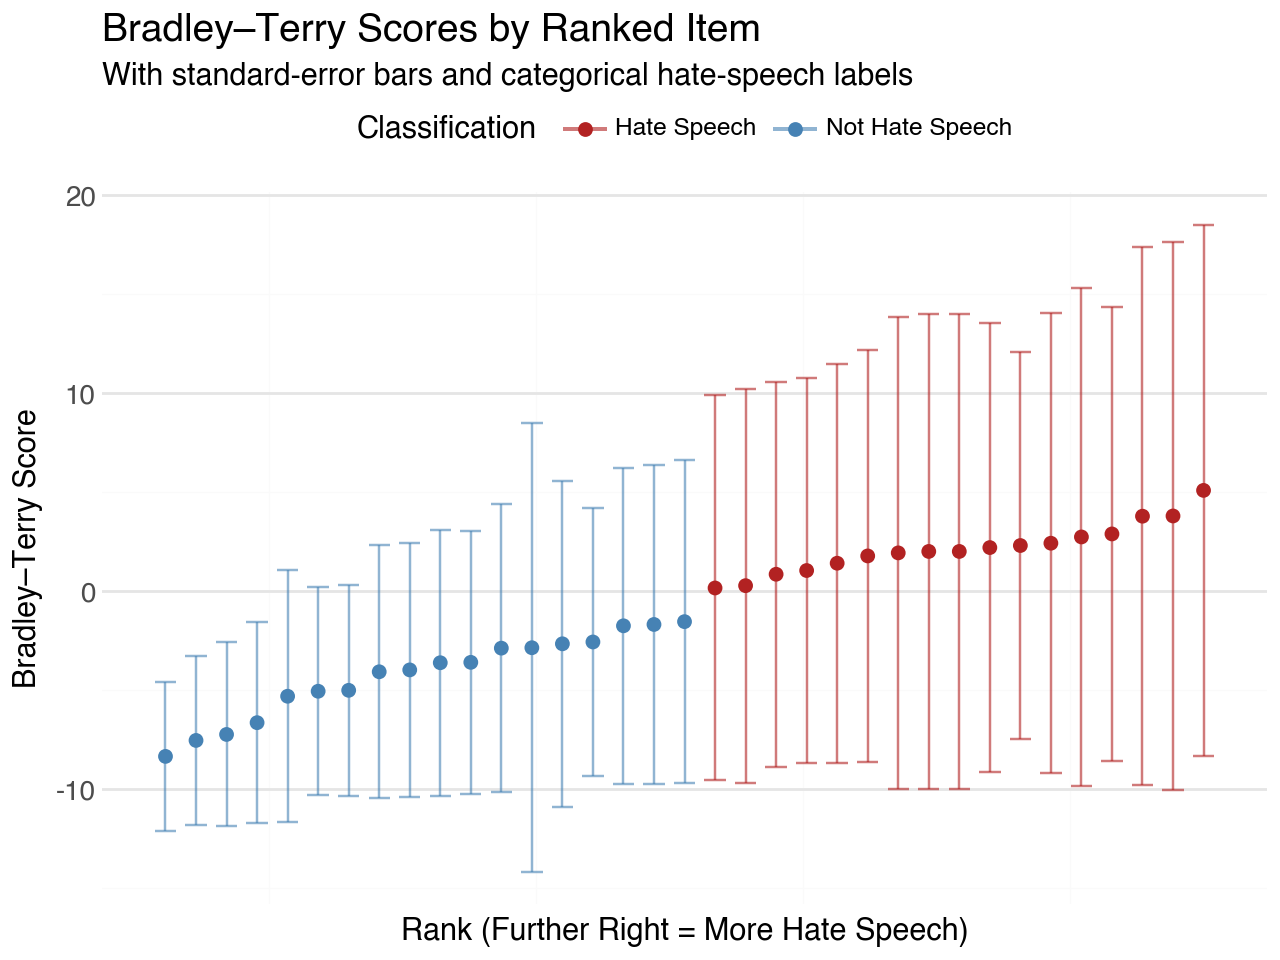

In [19]:
from plotnine.themes.themeable import panel_grid_major_x
from plotnine import (
    ggplot, aes, geom_point, geom_errorbar, scale_color_manual,
    labs, theme_minimal, theme, element_text, element_blank
)

# Recode cluster into categorical labels and precompute ymin and ymax for the errorbars safely for plotnine
classifications = classifications.assign(
    cluster_cat = classifications["kmeans_clusters"].map({
        1: "Hate Speech",
        0: "Not Hate Speech"
    }).astype("category"),
    ymin = classifications["Bradley_Terry_Score_full_ministral-3:8b"]
           - classifications["Bradley_Terry_SE_full_ministral-3:8b"],
    ymax = classifications["Bradley_Terry_Score_full_ministral-3:8b"]
           + classifications["Bradley_Terry_SE_full_ministral-3:8b"]
)

classifications['BT_full_score_rank'] = classifications["Bradley_Terry_Score_full_ministral-3:8b"].rank(pct=True)

from plotnine import (
    ggplot, aes, geom_point, geom_errorbar, scale_color_manual,
    labs, theme_minimal, theme, element_text
)

(
    ggplot(
        classifications,
        aes(
            x="BT_full_score_rank",
            y="Bradley_Terry_Score_full_ministral-3:8b",
            color="cluster_cat"
        )
    )
    + geom_errorbar(aes(ymin="ymin", ymax="ymax"), width=0.02, alpha=0.6)
    + geom_point(size=2)
    + scale_color_manual(
        values={
            "Hate Speech": "firebrick",
            "Not Hate Speech": "steelblue"
        }
    )
    + theme_minimal()
    + theme(
        legend_title=element_text(size=11, weight="bold"),
        legend_position="top",
        axis_title=element_text(size=11),
        axis_text=element_text(size=10),
        axis_text_x=element_blank(),
        plot_title=element_text(size=14, weight="bold"),
        plot_subtitle=element_text(size=11),
        panel_grid_major_x=element_blank()
    )
    + labs(
        title="Bradley–Terry Scores by Ranked Item",
        subtitle="With standard‑error bars and categorical hate‑speech labels",
        x="Rank (Further Right = More Hate Speech)",
        y="Bradley–Terry Score",
        color="Classification"
    )
)


We might also think - after reviewing some of the statements or reading the paper - that 3 categories makes theoretical sense: supportive speech, benign, and hate. Let's examine that possibility in the BT scores. 

In [ ]:
# Note, you don't have to save them separately, just doing this for the visualization. 
# This will autosave to scored_df and its parquet in the save_dir location

classifications = p.classify(
    score_col="Bradley_Terry_Score_full_ministral-3:8b",
    method='kmeans', # also has support for GMM and HDBSCAN
    n_clusters=3, # finds 3 categories
    output_col='kmeans_clusters_k3'
);

Classified 35 items into 3 clusters using kmeans on 'Bradley_Terry_Score_full_ministral-3:8b'.
                    count   mean    std    min    25%    50%    75%    max
kmeans_clusters_k3                                                        
0                     5.0 -7.008  1.135 -8.340 -7.534 -7.231 -6.636 -5.301
1                    13.0 -3.166  1.172 -5.048 -3.970 -2.871 -2.559 -1.532
2                    17.0  2.168  1.279  0.169  1.420  2.015  2.747  5.100
Pairadigm saved to: example_save_dir/
  Files written: metadata.json, data.parquet, pairwise_df.parquet, scored_df.parquet
Auto-saved updated scored dataframe with cluster assignments to: example_save_dir


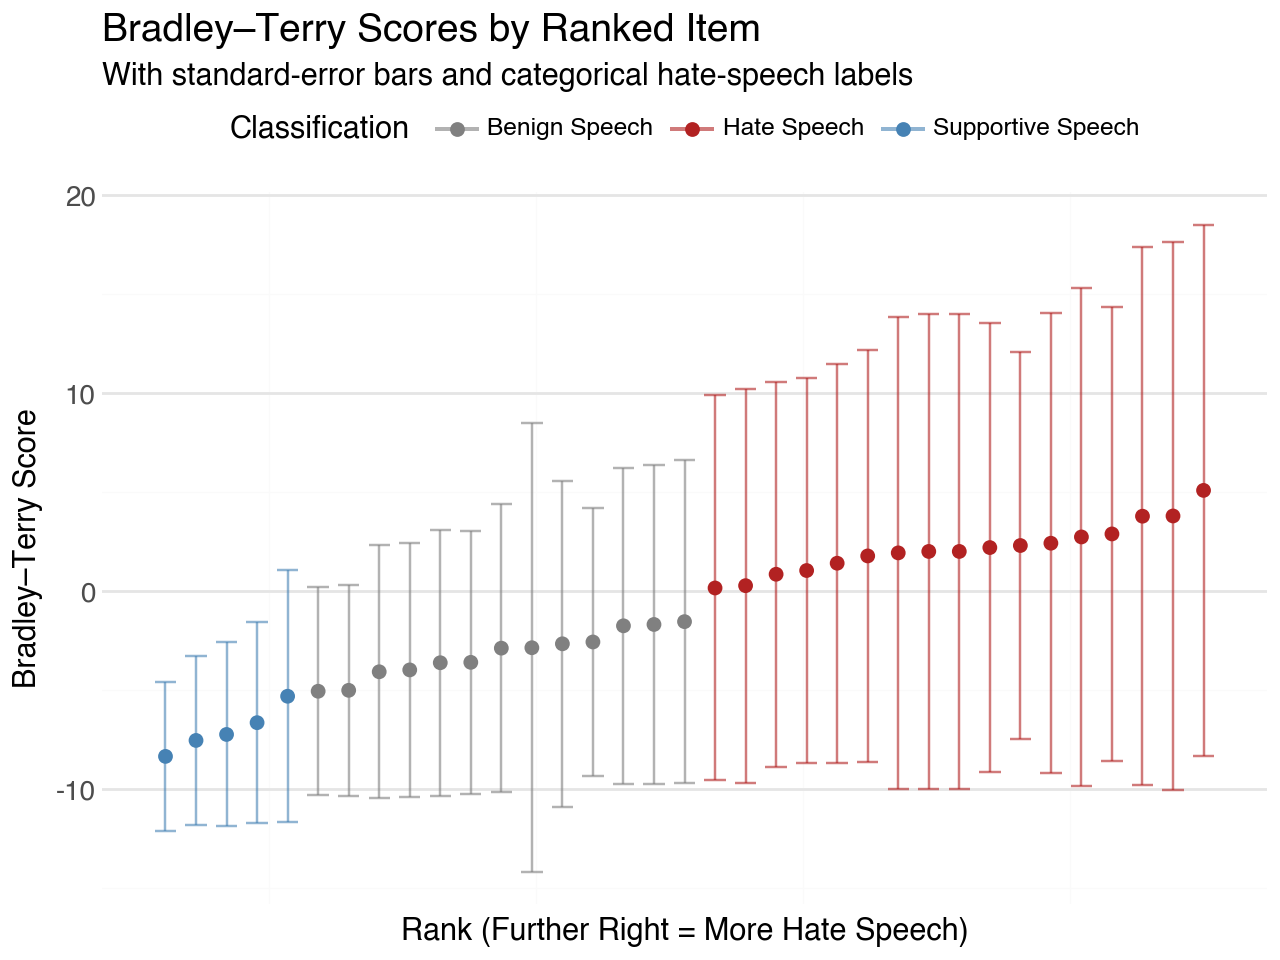

In [18]:
from plotnine import (
    ggplot, aes, geom_point, geom_errorbar, scale_color_manual,
    labs, theme_minimal, theme, element_text, element_blank
)

# Recode cluster into categorical labels and precompute ymin and ymax for the errorbars safely for plotnine
classifications = classifications.assign(
    cluster_cat = classifications["kmeans_clusters_k3"].map({
        2: "Hate Speech",
        1: "Benign Speech",
        0: "Supportive Speech"
    }).astype("category"),
    ymin = classifications["Bradley_Terry_Score_full_ministral-3:8b"]
           - classifications["Bradley_Terry_SE_full_ministral-3:8b"],
    ymax = classifications["Bradley_Terry_Score_full_ministral-3:8b"]
           + classifications["Bradley_Terry_SE_full_ministral-3:8b"]
)

classifications['BT_full_score_rank'] = classifications["Bradley_Terry_Score_full_ministral-3:8b"].rank(pct=True)

from plotnine import (
    ggplot, aes, geom_point, geom_errorbar, scale_color_manual,
    labs, theme_minimal, theme, element_text
)

(
    ggplot(
        classifications,
        aes(
            x="BT_full_score_rank",
            y="Bradley_Terry_Score_full_ministral-3:8b",
            color="cluster_cat"
        )
    )
    + geom_errorbar(aes(ymin="ymin", ymax="ymax"), width=0.02, alpha=0.6)
    + geom_point(size=2)
    + scale_color_manual(
        values={
            "Hate Speech": "firebrick",
            "Benign Speech": 'grey',
            "Supportive Speech": 'steelblue'
        }
    )
    + theme_minimal()
    + theme(
        legend_title=element_text(size=11, weight="bold"),
        legend_position="top",
        axis_title=element_text(size=11),
        axis_text=element_text(size=10),
        axis_text_x=element_blank(),
        plot_title=element_text(size=14, weight="bold"),
        plot_subtitle=element_text(size=11),
        panel_grid_major_x=element_blank()
    )
    + labs(
        title="Bradley–Terry Scores by Ranked Item",
        subtitle="With standard‑error bars and categorical hate‑speech labels",
        x="Rank (Further Right = More Hate Speech)",
        y="Bradley–Terry Score",
        color="Classification"
    )
)


# Additional Features

Now that you have a working idea of how `pairadigm` uses the LLMs to generate annotations and scores, here we'll demonstrate how to use it to validate LLM scores against manually generated annotations using the **Alternative Annotator Test (AltTest)** and the other evaluation tools discussed previously. 

Unfortunately, the Measuring Hate Speech dataset has a severe limitation in that the maximum number of items any 1 annotator examined is $26$. To generate reliable statistics using the AltTest *requires every annotator to have annotated at least $30$ items* and every item to have at least 3 annotators. Therefore we will use a different dataset for this demonstration: the 'Offensiveness' dataset of the POPQUORN study. Along the way we will also demonstrate other features of the package, including using proprietary models.

Citation: 

- Pei, J., & Jurgens, D. (2023). *When Do Annotator Demographics Matter? Measuring the Influence of Annotator Demographics with the POPQUORN Dataset*. In Proceedings of the 17th Linguistic Annotation Workshop (LAW-XVII), pp. 252–265. Association for Computational Linguistics.

In [1]:
# Imports (for those that started here)
import pandas as pd
import pairadigm as pdm
from dotenv import load_dotenv
import os
import datasets

/Users/mlchrzan/opt/anaconda3/envs/pairadigm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load the data directly from the URL
url = "https://raw.githubusercontent.com/Jiaxin-Pei/Potato-Prolific-Dataset/main/dataset/offensiveness/raw_data.csv"
offense = pd.read_csv(url)

offense

,instance_id,user_id,text,offensiveness,gender,race,age,occupation,education
0,530,0,"I think a lot of Dethklok songs use drop C, wo...",1.0,Man,White,35-39,Unemployed,High school diploma or equivalent
1,1280,0,There are relatively simple ways around all of...,1.0,Man,White,35-39,Unemployed,High school diploma or equivalent
2,621,0,Tell the british soldier in WW1 to shoot that ...,1.0,Man,White,35-39,Unemployed,High school diploma or equivalent
3,676,0,Top comment pretty much. I have gay friends an...,1.0,Man,White,35-39,Unemployed,High school diploma or equivalent
4,635,0,Don't tell them just let them and their liniag...,3.0,Man,White,35-39,Unemployed,High school diploma or equivalent
...,...,...,...,...,...,...,...,...,...
13031,471,262,They’re closed anti-vaxx Facebook groups. When...,1.0,Woman,Asian,54-59,Self-employed,College degree
13032,1033,262,Bioethics; an interesting field in which the w...,1.0,Woman,Asian,54-59,Self-employed,College degree
13033,740,262,Or they are really secure but hang around inse...,5.0,Woman,Asian,54-59,Self-employed,College degree
13034,894,262,Don't have to worry about being too big to fit...,4.0,Woman,Asian,54-59,Self-employed,College degree


`pairadigm` includes a `pair_from_ordinal()` function, which converts ordinal annotations into pairwise comparison data. It takes items that have been rated on an ordinal scale (e.g., 1–5 stars) and generates pairs of items along with inferred decisions about which item in each pair is "better" based on the individual scores given to each by their annotators.

These paired comparisons can then be used to run statistical tests like the AltTest to analyze comparative judgments by your LLM models. Rather than working directly with pointwise ratings, which [research has shown LLMs are unreliable for](https://aclanthology.org/2025.emnlp-main.1635.pdf), you can generate pairs and use them to understand and examine relative preferences.

NOTE: This method does not substitute well for data collected in a pairwise fashion, as raters may have been more inconsistent with absolute judgements. You can use it for exploration, but for rigorous analysis we recommend collecting raw pairwise comparison data. 

In [ ]:
# Convert the ordinal ratings to pairs
offense_paired = pdm.pair_from_ordinal(
    data=offense,
    annotator_id_col='user_id',
    ordinal_cols='offensiveness',
    max_pairs_per_item=25, # large because we'll need to filter down
    item_id_col='instance_id',
    item_text_col='text',
    method='random',
    random_seed=42,
    min_annotators_per_pair=2, 
    min_pairs_per_annotator=50
)

# Check for having enough data for the AltTest
nunique_items = len(set(offense_paired['item1']).union(offense_paired['item2']))
print(f"Number of unique items: {nunique_items}")
print(f"Number of pairs: {offense_paired.shape[0]}")
print(f"Number of annotators: {offense_paired.shape[1]-6}")
print("Top 5 rows:")
offense_paired.head()

/Users/mlchrzan/Library/CloudStorage/OneDrive-Personal/Professional/Data Science/Personal Projects/pairadigm/pairadigm/core.py:2859: UserWarning: This function is still under development and may not work as intended. Please use with caution.
  warnings.warn(


[AltTest pruning] 18735 → 164 pairs, 262 → 6 annotator columns retained (min_annotators_per_pair=2, min_pairs_per_annotator=50).
Generated 164 pairs from ordinal annotations (method='random').
Number of unique items: 107
Number of pairs: 164
Number of annotators: 6
Top 5 rows:


,item1,item2,mean_offensiveness_1,mean_offensiveness_2,annotator_offensiveness_233,annotator_offensiveness_36,annotator_offensiveness_9,annotator_offensiveness_205,annotator_offensiveness_210,annotator_offensiveness_14,text_1,text_2
0,1379,49,2,2,Text1,Tie,NaN,NaN,NaN,NaN,Fuck no. I want to do stuff. I would be okay i...,"""Would you like to invest in our grow up plan""..."
1,839,719,2,2,NaN,NaN,Text2,Text2,NaN,NaN,"No, welcome to American politics.",The hell is that font?
2,968,883,4,2,NaN,NaN,Text1,Tie,NaN,NaN,"Yeah they don't call them property directly, t...",Holy crap this is amazing
3,483,1393,1,2,NaN,NaN,NaN,NaN,Tie,Tie,I don 't know what Facebook you have but I jus...,"As you can tell by my tag, I'm a Scout. I am c..."
4,828,616,2,3,Text2,Tie,NaN,NaN,NaN,NaN,He is almost out of his teens. It is not “fair...,"... from the same guy that used the word ""nigg..."


In [ ]:
# Examine the number of annotations per annotator
offense_paired[[c for c in offense_paired.columns if c.startswith("annotator")]].notna().sum()

annotator_offensiveness_233    50
annotator_offensiveness_36     50
annotator_offensiveness_9      59
annotator_offensiveness_205    59
annotator_offensiveness_210    55
annotator_offensiveness_14     55
dtype: int64

In [ ]:
# Check that each observation has at least 2 annotators 
# 3 would be ideal, but you'll see if you play around with pair_from_ordinal() that this is harder to achieve in this dataset. 
annotator_cols = [c for c in offense_paired.columns if c.startswith("annotator_")]
offense_paired["non_nan_annotators"] = offense_paired[annotator_cols].notna().sum(axis=1)
offense_paired.sort_values('non_nan_annotators', ascending=True).head(5)

,item1,item2,mean_offensiveness_1,mean_offensiveness_2,annotator_offensiveness_233,annotator_offensiveness_36,annotator_offensiveness_9,annotator_offensiveness_205,annotator_offensiveness_210,annotator_offensiveness_14,text_1,text_2,non_nan_annotators
0,1379,49,2,2,Text1,Tie,NaN,NaN,NaN,NaN,Fuck no. I want to do stuff. I would be okay i...,"""Would you like to invest in our grow up plan""...",2
105,1287,258,2,1,NaN,NaN,NaN,NaN,Tie,Tie,While it may be true in individual cases that ...,I will never understand the thought process be...,2
106,229,477,2,3,Text2,Text1,NaN,NaN,NaN,NaN,Still not 2.5 inches. 1 inch is about as long ...,"Not where I live, and they sure as hell don’t ...",2
107,670,1274,1,2,Tie,Tie,NaN,NaN,NaN,NaN,You'd be crazy to pass up a bargain like this,The Grand Theft Auto game series,2
108,217,263,2,2,NaN,NaN,NaN,NaN,Tie,Tie,"It may suprise you, but sexual assault is not ...",The only good Ben Garrision comic I've seen is...,2


Now we've verified that we have everything needed to run the AltTest: multiple annotators per item and every annotator has at least 30 annotations.

NOTE, however, that each item *does not have at least 5 pairs per item*, so we would not want to generate BT scores from this set as the estimates are likely far too uncertain. However, for showing the AltTest this will suffice. 

In [ ]:
# CGCoT Prompts for "offensiveness", designed with the help of Gemini 3.1 Pro (see below)
cgcot_prompts_offense = [
    "Who or what is the primary focus or target of the text? Text: {text}",
    "If the text primarily focuses on a specific target based on your above answer, does the text express aversion, dislike, distrust, blame, criticism, or negative sentiments towards that target? If the text focuses on neither a specific target nor group, answer 'N/A'. Text: {text}",
    "We define offensiveness as how likely the text is to be perceived as inappropriate, insulting, or harmful in a general social context. Considering factors such as language, tone, and potential harm to individuals or groups, does the text contain blunt phrasing, disrespectful or derogatory content, severe slurs, threats, dehumanizing language, or hate speech? Text: {text}"
]

NOTE: These prompts were generated using Gemini 3.1 Pro prompted as such with the pairadigm repo and Wu et. al. CGCoT paper attached: 
```
I'm interested in using pairadigm to score text on offensiveness, following the study and data laid out in this repo: https://github.com/Jiaxin-Pei/Potato-Prolific-Dataset/tree/main. Write a set of 4-5 CGCoT prompts for surfacing nuance of offensiveness in text based on this work and others. 
```

In [ ]:
# Load our API key
load_dotenv(".env")
OPENAI_API_KEY=os.getenv('OPENAI_API_KEY')

In [ ]:
# Initialize the new pairadigm
p_adv = pdm.Pairadigm(
    data=offense_paired,
    # NOTE: Since the data is already paired, this changes the values passed to the instance. 
    paired=True, 
    item_id_cols=['item1', 'item2'],
    item_text_cols=['text_1', 'text_2'], 
    annotated=True, # Data is already annotated as well
    annotator_cols=[c for c in offense_paired.columns if c.startswith("annotator_")],
    # These other parameters below are the same as before
    cgcot_prompts=cgcot_prompts_offense,
    model_name=['gpt-5.4-nano', 'gpt-5.4-mini'], # Again, feel free to swap in your model(s) of choice here
    api_key=[OPENAI_API_KEY, OPENAI_API_KEY], # Note that the API key must match the index of the model name
    base_url=["https://us.api.openai.com/v1", "https://us.api.openai.com/v1"],
    target_concept='offensiveness',
    save_dir="example_adv_save_dir"
)

# Review Clients
p_adv.get_clients_info()

,index,model_name,provider
0,0,gpt-5.4-nano,openai
1,1,gpt-5.4-mini,openai


In [20]:
# Check clients 
p_adv.test_clients_connection(test_prompt='What is the best pizza spot in Detroit?', return_responses=True)

Testing LLM client connections using: 'What is the best pizza spot in Detroit?'...
  gpt-5.4-nano: MODEL OK
  gpt-5.4-mini: MODEL OK


{'gpt-5.4-nano': 'The best pizza spot in Detroit depends on what style you want, but the most consistently top-rated “go-to” choice is **Buddy’s Pizza** (especially for Detroit-style square pies).',
 'gpt-5.4-mini': 'The top Detroit pizza spot is often considered **Buddy’s Pizza**, especially for classic Detroit-style pizza.'}

Way faster!

Now that we're using proprietary APIs, we can also demonstrate that `pairadigm` has built-in functionality to estimate the cost of the pipeline based on how much data you've passed using the `estimate_costs()` method. These esimates can be run at the beginning or at each step of the processes. 

NOTE: These costs are estimated using the token prices at the time of the publication of the most recent version of `pairadigm`. Since costs change frequently, the function gives you the ability to enter custom cost per 1M token information as well. 

In [ ]:
# Estimate token costs
p_adv.estimate_costs()


          LLM API COST ESTIMATION
DISCLAIMER: These are rough heuristics for token counting
and pricing based on general models. They do not reflect
real-time constraints, retries, or precise tokenizers.
------------------------------------------------------------
Client [0]: gpt-5.4-nano
Pricing used: $0.200 per 1M input | $1.250 per 1M output
  [Breakdowns] Items: 107, Expected Input: ~44,927, Expected Output: ~64,200
  [Pairwise] Pairs: 164, Expected Input: ~88,232, Expected Output: ~8,200
  >>> Estimated Cost: $0.1171
------------------------------------------------------------
Client [1]: gpt-5.4-mini
Pricing used: $0.750 per 1M input | $4.500 per 1M output
  [Breakdowns] Items: 107, Expected Input: ~44,927, Expected Output: ~64,200
  [Pairwise] Pairs: 164, Expected Input: ~63,960, Expected Output: ~8,200
  >>> Estimated Cost: $0.4075
------------------------------------------------------------


Great! Now that we've set everything up and the costs look reasonable, we can go ahead and generate our CGCoT breakdowns and paired comparisons, just like before. 

In [18]:
p_adv.generate_breakdowns()


Generating breakdowns for 107 unique items using: gpt-5.4-nano


[gpt-5.4-nano]: 100%|██████████| 107/107 [00:39<00:00,  2.69it/s]


Completed: 107/107 items

Generating breakdowns for 107 unique items using: gpt-5.4-mini


[gpt-5.4-mini]: 100%|██████████| 107/107 [00:36<00:00,  2.93it/s]

Completed: 107/107 items

Breakdowns added to [object].pairwise_df — column(s): breakdown1_gpt-5.4-nano, breakdown2_gpt-5.4-nano, breakdown1_gpt-5.4-mini, breakdown2_gpt-5.4-mini
Pairadigm saved to: example_adv_save_dir/
  Files written: metadata.json, data.parquet, pairwise_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: example_adv_save_dir


In [19]:
p_adv.generate_pairwise_annotations()

[gpt-5.4-mini] Pairwise comparisons: 100%|██████████| 164/164 [00:24<00:00,  6.74it/s]

Pairadigm saved to: example_adv_save_dir/
  Files written: metadata.json, data.parquet, pairwise_df.parquet
  Note: API keys and base URLs are NOT saved. You will need to supply them again when loading (via environment variables or the api_key and base_url parameters).
Auto-saved to: example_adv_save_dir


,item1,item2,mean_offensiveness_1,mean_offensiveness_2,annotator_offensiveness_233,annotator_offensiveness_36,annotator_offensiveness_9,annotator_offensiveness_205,annotator_offensiveness_210,annotator_offensiveness_14,text_1,text_2,breakdown1_gpt-5.4-nano,breakdown2_gpt-5.4-nano,breakdown1_gpt-5.4-mini,breakdown2_gpt-5.4-mini,decision_gpt-5.4-nano,justification_gpt-5.4-nano,decision_gpt-5.4-mini,justification_gpt-5.4-mini
0,1379,49,2,2,Text1,Tie,NaN,NaN,NaN,NaN,Fuck no. I want to do stuff. I would be okay i...,"""Would you like to invest in our grow up plan""...",Original Text: Fuck no. I want to do stuff. I ...,"Original Text: ""Would you like to invest in ou...",Original Text: Fuck no. I want to do stuff. I ...,"Original Text: ""Would you like to invest in ou...",Text1,Description 1 \nJUSTIFICATION: Description 1 ...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...
1,839,719,2,2,NaN,NaN,Text2,Text2,NaN,NaN,"No, welcome to American politics.",The hell is that font?,"Original Text: No, welcome to American politic...",Original Text: The hell is that font?\nThe pri...,"Original Text: No, welcome to American politic...",Original Text: The hell is that font?\nThe mai...,Text2,Description 2\n\nJUSTIFICATION: Description 2 ...,Text2,"FINAL ANSWER: ""Description 2""\nJUSTIFICATION: ..."
2,968,883,4,2,NaN,NaN,Text1,Tie,NaN,NaN,"Yeah they don't call them property directly, t...",Holy crap this is amazing,Original Text: Yeah they don't call them prope...,Original Text: Holy crap this is amazing\nThe ...,Original Text: Yeah they don't call them prope...,Original Text: Holy crap this is amazing\nThe ...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...
3,483,1393,1,2,NaN,NaN,NaN,NaN,Tie,Tie,I don 't know what Facebook you have but I jus...,"As you can tell by my tag, I'm a Scout. I am c...",Original Text: I don 't know what Facebook you...,"Original Text: As you can tell by my tag, I'm ...",Original Text: I don 't know what Facebook you...,"Original Text: As you can tell by my tag, I'm ...",Text1,Description 1\n\nJUSTIFICATION: Description 1 ...,Text2,"FINAL ANSWER: ""Description 2""\nJUSTIFICATION: ..."
4,828,616,2,3,Text2,Tie,NaN,NaN,NaN,NaN,He is almost out of his teens. It is not “fair...,"... from the same guy that used the word ""nigg...",Original Text: He is almost out of his teens. ...,Original Text: ... from the same guy that used...,Original Text: He is almost out of his teens. ...,Original Text: ... from the same guy that used...,Text1,Description 2\n\nJUSTIFICATION: Description 2 ...,Text2,"FINAL ANSWER: ""Description 2""\nJUSTIFICATION: ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,1379,1495,2,2,Text1,Tie,NaN,NaN,NaN,NaN,Fuck no. I want to do stuff. I would be okay i...,Offer myself as their slave and informant.,Original Text: Fuck no. I want to do stuff. I ...,Original Text: Offer myself as their slave and...,Original Text: Fuck no. I want to do stuff. I ...,Original Text: Offer myself as their slave and...,Text2,Description 2 \nJUSTIFICATION: Description 2 ...,Text2,"FINAL ANSWER: ""Description 2""\nJUSTIFICATION: ..."
160,305,383,2,1,NaN,NaN,NaN,NaN,Text1,Tie,Yeah. I got married and had two kids over the ...,And then you get echo chambers of this nonsens...,Original Text: Yeah. I got married and had two...,Original Text: And then you get echo chambers ...,Original Text: Yeah. I got married and had two...,Original Text: And then you get echo chambers ...,Text1,FINAL ANSWER: Description 1 \nJUSTIFICATION: ...,Text1,"FINAL ANSWER: ""Description 1"" \nJUSTIFICATION..."
161,950,1429,3,1,NaN,NaN,Tie,Text1,NaN,NaN,Ass? That would obliterate a pair of testicles.,where is the code? ​,Original Text: Ass? That would obliterate a pa...,Original Text: where is the code? ​\nThe prima...,Original Text: Ass? That would obliterate a pa...,Original Text: where is the code? ​\nThe text ...,Text1,FINAL ANSWER: Description 1 \nJUST

And we can use our previously demonstrated evaluation metrics as well. 

In [4]:
p_adv.check_transitivity()

{'annotator_offensiveness_233': (1.0, 0, 3),
 'annotator_offensiveness_36': (1.0, 0, 3),
 'annotator_offensiveness_9': (1.0, 0, 2),
 'annotator_offensiveness_205': (1.0, 0, 2),
 'annotator_offensiveness_210': (1.0, 0, 4),
 'annotator_offensiveness_14': (1.0, 0, 4),
 'decision_gpt-5.4-nano': (0.8888888888888888, 1, 9),
 'decision_gpt-5.4-mini': (1.0, 0, 9)}

In [ ]:
p_adv.irr() # Note that now it also calculates the IRR among the manual ("HUMAN") annotators


INTER-RATER RELIABILITY RESULTS

HUMAN ANNOTATORS:
  Method: Krippendorff
  Score: 0.895
  Interpretation: Almost Perfect
  Annotators: 6
  Items: 164

LLM ANNOTATORS:
  Method: Cohens Kappa
  Score: 0.585
  Interpretation: Moderate
  Annotators: 2
  Items: 164

ALL ANNOTATORS:
  Method: Krippendorff
  Score: 0.849
  Interpretation: Almost Perfect
  Annotators: 8
  Items: 164



,group,method,score,n_annotators,n_items,interpretation,error
0,human,krippendorff,0.895276,6,164,Almost Perfect,None
1,llm,cohens_kappa,0.585366,2,164,Moderate,None
2,all,krippendorff,0.849124,8,164,Almost Perfect,None


In [8]:
p_adv.dawid_skene_annotator_ranking(random_seed=42, num_classes=3)

Ranking 8 annotators across 164 instances...

DAWID-SKENE ANNOTATOR RANKING
Converged at iteration: 100

Top 5 Most Reliable Annotators:
   rank                    annotator  reliability   type
0     1        decision_gpt-5.4-mini     0.486452    LLM
1     2  annotator_offensiveness_205     0.486119  Human
2     3  annotator_offensiveness_233     0.482498  Human
3     4    annotator_offensiveness_9     0.447800  Human
4     5        decision_gpt-5.4-nano     0.365496    LLM




,annotator,reliability,type,rank
0,decision_gpt-5.4-mini,0.486452,LLM,1
1,annotator_offensiveness_205,0.486119,Human,2
2,annotator_offensiveness_233,0.482498,Human,3
3,annotator_offensiveness_9,0.447800,Human,4
4,decision_gpt-5.4-nano,0.365496,LLM,5
5,annotator_offensiveness_36,0.322982,Human,6
6,annotator_offensiveness_14,0.219345,Human,7
7,annotator_offensiveness_210,0.171587,Human,8


## The Alternative Annotator Test (AltTest)

In these results, we can see that a few of the manual annotators appear to be particularly disagreeing on the construct (much lower reliability than the others). While not depicted, we checked this (and you can replicate it as an exercise if you'd like) and the lower reliabilities are then when calculated with just the manual annotators as well without the LLMs. This brings us to a key point in thinking about how to use the validation metrics to craft a validation argument for using (or not using!) an LLM as an annotator. 

The Dawid-Skene model gives us a powerful probabilistic lens for understanding *how reliably* each annotator labels — but it has a fundamental limitation when applied to LLM judges: it can only tell us how well an annotator *agrees with the crowd.* Which in this case also includes the LLM judges! It is an open area of research in how we might derive decision rules based on Dawid-Skene reliabilities estimated with LLMs in the crowd, especially crowds that may contain baised manual annotators. In the context of pairwise preference evaluation, this raises a deeper question: **does an annotator's agreement with others reflect genuine judgment quality, or simply shared bias?**

The **Alternative Annotator Test (AltTest)** is designed to help answer this. Rather than asking "how consistent is this annotator with the group?", it asks: **"Could this annotator serve as a drop-in replacement for other human judgments?"**

### How the AltTest Works

The intuition behind the AltTest comes from a simple counterfactual: if you swapped out your manual annotators for a given LLM judge, would the *conclusions you draw from your evaluation* hold up?

Concretely, for each pair of models being compared in your evaluation, the AltTest measures whether the LLM judge assigns values in a pattern consistent with manual annotators — not just in aggregate, but **at the level of individual comparisons**. The key metric is a **win rate against the human panel**: for a given item, does the LLM's preference align with what a randomly sampled manual annotator would choose?

A judge that meets the **0.50 win rate threshold** is one whose preferences are statistically indistinguishable from drawing a preference from the human pool — it is, in effect, a plausible manual annotator. This logic is why at least 3 annotators are needed - any less and its laughably easy to pass 50%. Falling below this threshold suggests the LLM judge is systematically diverging from human judgment in ways that matter for your evaluation conclusions.

Next, we show the AltTest results for our data thus far. NOTE however that here since we only have 2 human annotators per observation, the AltTest results are to be taken with a mound of salt. In a robust study, at least 3 manual annotators should be used for the comparison. 

In [ ]:
# Run the AltTest at a specific epsilon value
p_adv.alt_test(
    scoring_function='accuracy',
    epsilon=0.05, # Cost-benefit hyperparameter, 
    # recommended values are 0.05 if annotators were crowdworkers 
    # 0.10 for trained annotators, 0.20 for experts
    q_fdr=0.05, # false dicsovery correction
    test_all_llms=True # test every LLM or just 1? 
)

Testing all 2 LLM decision columns: ['decision_gpt-5.4-nano', 'decision_gpt-5.4-mini']
Using LLM decision column: decision_gpt-5.4-nano
Using LLM decision column: decision_gpt-5.4-nano

ALT-TEST RESULTS - GPT-5.4-NANO
Winning Rate (ω): 0.000
Advantage Probability: 0.716
Tested against 6 human annotators

Using LLM decision column: decision_gpt-5.4-mini

ALT-TEST RESULTS - GPT-5.4-MINI
Winning Rate (ω): 0.167
Advantage Probability: 0.745
Tested against 6 human annotators



{'gpt-5.4-nano': (0.0, 0.7156445814072933),
 'gpt-5.4-mini': (0.16666666666666666, 0.744910118130457)}

While Calderon et al. provide guidance on setting the $\epsilon$ hyperparameter values based on annotator expertise, we recommend evaluating the models' performance over a range of values to get a sense of their performance. We provide a method for visualizing this performance in the package. 

Testing 36 epsilon values from -0.1 to 0.25...


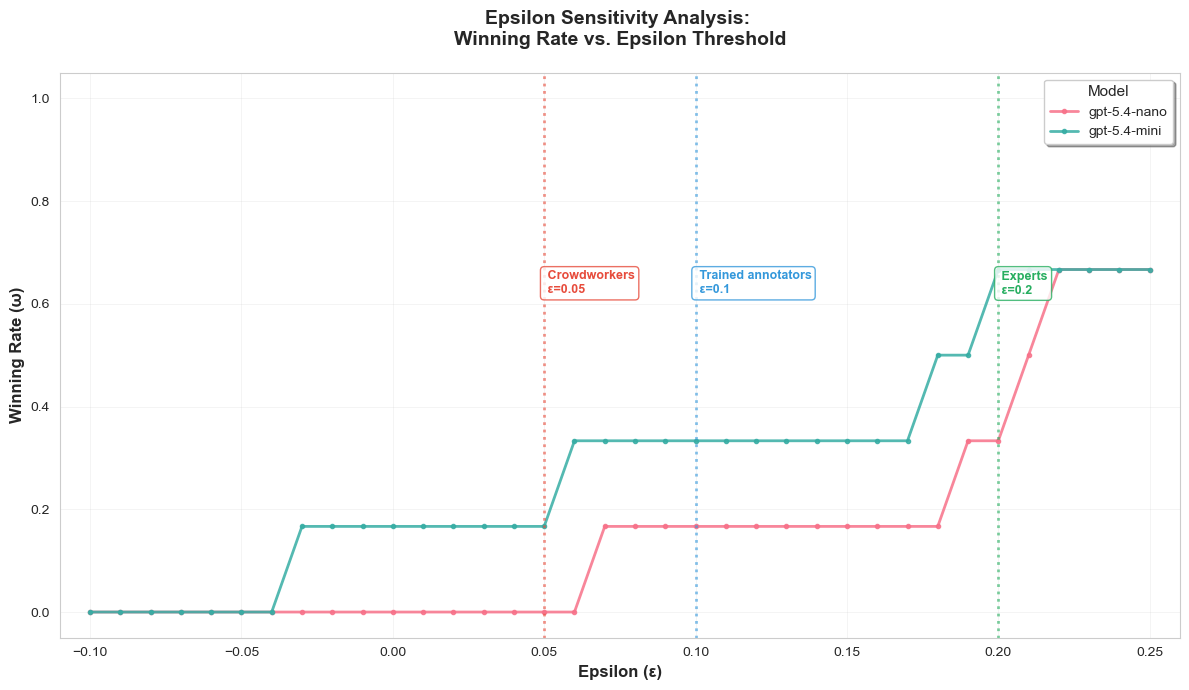

In [ ]:
# Plotting win-rate across epsilon values
p_adv.plot_epsilon_sensitivity()

### Reconciling DS Reliability and AltTest Results

From these results we see that while GPT-5.4-mini had the highest reliability it couldn't pass the AltTest without a much larger $\epsilon$ value than is justified by the annotator pool. This should give us some caution in selecting it as an LLM to scale annotations on this construct. 

These two metrics are complementary but **measure fundamentally different things**, and it's important to consider them together. The table below illustrates how to interpret the four possible combinations across DS and AltTest evaluations:


| DS Reliability | AltTest Win Rate | Interpretation |
| :--- | :--- | :--- |
| High | ≥ 0.50 | ✅ **Strong judge.** Consistent with the group *and* aligned with human preferences. Use with confidence. |
| High | < 0.50 | ⚠️ **Consistent but misaligned.** The LLM agrees well internally but may reflect a shared bias among non-human annotators — or be rewarding something humans don't value. Treat conclusions with caution. |
| Low | ≥ 0.50 | 🔍 **Noisy but human-like.** The LLM's preferences are harder to predict from the group, but when it does make a call, it tends to be in a human-plausible direction. May be usable with aggregation, but inspect failure modes. |
| Low | < 0.50 | ❌ **Weak judge.** Neither consistent nor human-aligned. Avoid using as a standalone evaluator. |

The most important case to flag is **high DS reliability paired with a failing AltTest**. This is the "confident but wrong" scenario: the LLM judge is internally self-consistent and agrees well with other annotators in the pool, which the DS model rewards with high reliability. But the AltTest reveals that this consistency may reflect a *systematic deviation* from human preferences — for instance, an LLM judge that reliably prefers longer responses, more formal language, or outputs from models in its own family. High agreement within a panel of LLM judges does not rescue this; it may simply mean the judges share the same blind spots.

Conversely, a judge with modest DS reliability but a passing AltTest is not necessarily one to discard. It may be capturing a broader diversity of human-like perspectives, making it noisier to model but not less *valid*.

### Practical Guidance

When evaluating your annotator pool, we recommend the following workflow:

1. **Start with DS reliability** to identify annotators who are erratic or random — low diagonal values in their confusion matrix are a red flag regardless of the AltTest result.
2. **Apply the AltTest** to the remaining annotators to check for systematic misalignment with human judgment, especially among your LLM judges.
3. **Flag the high-reliability / low-AltTest cases** for manual review. These are your highest-priority audit targets, since they will have outsized influence on your aggregated labels (DS up-weights reliable annotators) while potentially steering conclusions in a non-human direction.

Used together, DS reliability and the AltTest give you both a *quantitative* handle on annotator noise and a *validity* check on whether your judges are measuring what you actually care about.